**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()
M_TAIL = 100

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")

**Cell 2 — Load and combine returns**

In [2]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

**Cell 3 — Portfolio negative log-returns and top-m tail**

In [3]:
x_full = -returns.sum(axis=1).values
n = len(x_full)
x_sorted = np.sort(x_full)[::-1]
m = M_TAIL
x_top = x_sorted[:m]

**Cell 4 — Empirical Mean Excess Function (MEF)**

In [4]:
t_vals = x_sorted[:m + 1]

MEF = np.array([
    (x_full[x_full > t] - t).mean() if np.any(x_full > t) else np.nan
    for t in t_vals
])

**Cell 5 — GPD Mean Excess Function (fit via MLE)**

In [5]:
threshold = x_sorted[m]
exceedances = x_full[x_full > threshold] - threshold

xi, loc, sigma = genpareto.fit(exceedances, floc=0)
gpd_mef = (sigma + xi * (t_vals - threshold)) / (1 - xi)

**Cell 6 — Hill Estimator and Pareto Mean Excess**

In [7]:
log_diffs = np.log(x_top) - np.log(x_sorted[m])
gamma_hill = np.mean(log_diffs)
alpha_hill = 1 / gamma_hill

pareto_mef = t_vals / (alpha_hill - 1)

**Cell 7 — Plot, display and save**

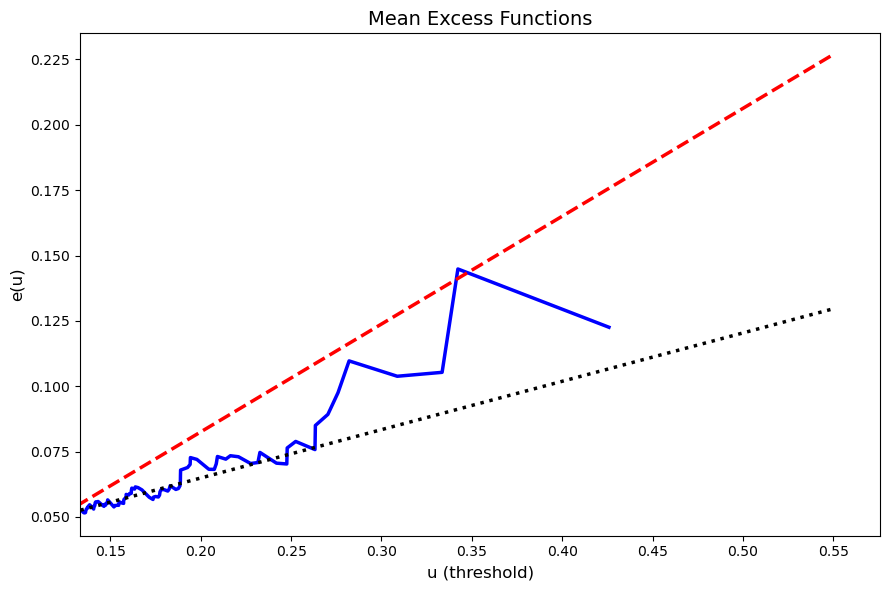

GPD fit — xi (gamma): 0.1561, sigma: 0.0443
Hill estimator — alpha: 3.4236, gamma = 1/alpha: 0.2921


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(t_vals, MEF, color="blue", linewidth=2.5, label="Empirical MEF")
ax.plot(t_vals, gpd_mef, color="black", linewidth=2.5, linestyle="dotted", label="GPD MEF (MLE fit)")
ax.plot(t_vals, pareto_mef, color="red", linewidth=2.5, linestyle="dashed", label="Pareto MEF (Hill estimator)")

ax.set_xlim(max(t_vals.min(), 0.03), t_vals.max() * 1.05)
ax.set_xlabel("u (threshold)", fontsize=12)
ax.set_ylabel("e(u)", fontsize=12)
ax.set_title("Mean Excess Functions", fontsize=14)
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mean_excess_functions.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()

print(f"GPD fit — xi (gamma): {xi:.4f}, sigma: {sigma:.4f}")
print(f"Hill estimator — alpha: {alpha_hill:.4f}, gamma = 1/alpha: {gamma_hill:.4f}")